In [1]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 3.22 MiB/s, done.
Resolving deltas: 100% (57/57), done.


In [2]:
!pip install insightface onnxruntime-gpu --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 11.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 77.1 MB/s eta 0:00:00


In [3]:
!pip install facenet-pytorch ninja lpips torchmetrics --force-reinstall --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 285.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 305.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 315.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 239.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 153.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 252.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 214.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 191.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 191.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!pip install kagglehub


In [2]:
import sys
sys.path.insert(0, "/content/stylegan2-ada-pytorch")

In [3]:
import os

# Create a folder for models
os.makedirs('models', exist_ok=True)

# Download the stylegan2-ada-pytorch FFHQ model (resolution 1024x1024)
# This is hosted by NVIDIA
!wget https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl -O models/ffhq.pkl

print("Download complete.")

--2026-02-25 09:19:57--  https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl
Resolving nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)... 3.163.165.95, 3.163.165.26, 3.163.165.60, ...
Connecting to nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)|3.163.165.95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381624121 (364M) [binary/octet-stream]
Saving to: ‘models/ffhq.pkl’

models/ffhq.pkl     100%[===================>] 363.94M   369MB/s    in 1.0s    

2026-02-25 09:19:59 (369 MB/s) - ‘models/ffhq.pkl’ saved [381624121/381624121]

Download complete.


In [4]:
import torch
import pickle
import copy
import dnnlib
import legacy # From the cloned repo

import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
from facenet_pytorch import InceptionResnetV1
from torchvision import transforms
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cosine
from tqdm import tqdm
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio
import lpips
import math
import random

import insightface
from insightface.app import FaceAnalysis

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [6]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensure deterministic behavior (might slow down slightly)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(0)

In [7]:
class StyleGANGenerator(torch.nn.Module):
    def __init__(self, network_pkl):
        super(StyleGANGenerator, self).__init__()
        print(f'Loading network from "{network_pkl}"...')

        with dnnlib.util.open_url(network_pkl) as f:
            # Load the network from the pickle file
            network_dict = legacy.load_network_pkl(f)
            self.G = network_dict['G_ema'].to(device)
            self.D = network_dict['D'].to(device)
            self.D.eval()
            for param in self.D.parameters():
                param.requires_grad = False

        # Lock the weights (we never train the generator itself)
        self.G.eval()
        for param in self.G.parameters():
            param.requires_grad = False

        # Store useful constants
        self.w_dim = self.G.w_dim  # Usually 512
        self.num_ws = self.G.mapping.num_ws # Usually 18 for 1024x1024
        print(f'Loaded network! (w_dim: {self.w_dim}, num_ws: {self.num_ws})')

    def forward(self, w_plus_vector):
        """
        Input: w_plus_vector of shape (Batch, 18, 512)
        Output: Image tensor (Batch, 3, 1024, 1024) in range [-1, 1]
        """
        # synthesis() expects input to be split by layers, but w+ is already shaped correctly
        # noise_mode='const' means we don't add random noise to hair/pores every time (deterministic)
        img = self.G.synthesis(w_plus_vector, noise_mode='const')
        return img

    def get_mean_w(self, n_samples=4096, seed=0):
        """
        Get the average latent code (W space).
        Optimizing starting from the Mean Face is much faster/easier.
        """
        torch.manual_seed(seed)
        z = torch.randn(n_samples, self.G.z_dim, device=device)
        w = self.G.mapping(z, None) # Convert z to w
        w_avg = w.mean(0, keepdim=True)

        return w_avg

# Initialize the model
generator = StyleGANGenerator('models/ffhq.pkl')
print("Generator Loaded Successfully!")

Loading network from "models/ffhq.pkl"...
Loaded network! (w_dim: 512, num_ws: 18)
Generator Loaded Successfully!


In [8]:
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)
transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor()
])

  0%|          | 0.00/107M [00:00<?, ?B/s]

# General Functions

In [9]:
class VGGPerceptualLoss(nn.Module):
    def __init__(self, resize=True):
        super(VGGPerceptualLoss, self).__init__()

        # Load VGG16
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features

        # Slicing up to layer 16 (ReLU3_3) is standard.
        self.blocks = nn.Sequential(*list(vgg.children())[:16]).eval()

        # Freeze the model weights
        for param in self.blocks.parameters():
            param.requires_grad = False

        # VGG specific normalization
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)
        self.resize = resize

    def forward(self, generated_img, target_img):
        # Assuming the images are in [0, 1] range:
        gen_norm = (generated_img - self.mean) / self.std
        target_norm = (target_img - self.mean) / self.std

        # Extract features
        gen_features = self.blocks(gen_norm)
        target_features = self.blocks(target_norm)

        # Calculate L2 loss between the feature maps
        loss = torch.nn.functional.mse_loss(gen_features, target_features)
        return loss

perceptual_criterion = VGGPerceptualLoss().to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:08<00:00, 66.8MB/s]


In [10]:
def display_grid_graphs(metrics_dict, n_cols=2, steps_log=None, log_scale_keys=None, figsize=None):
    """
    Plots multiple graphs in a grid.

    Args:
        metrics_dict (dict): Dictionary where Key is the Title and Value is the list of data.
        n_cols (int): Number of columns in the grid.
        steps_log (list): list of step jumps. If None, include all the steps.
        log_scale_keys (list): List of keys from metrics_dict that should be plotted in log scale.
        figsize (tuple): Optional custom size (width, height). If None, calculates automatically.
    """
    if steps_log is None:
        steps_log = list(range(len(next(iter(metrics_dict.values())))))

    if log_scale_keys is None:
        log_scale_keys = []

    # Calculate Grid Dimensions
    n = len(metrics_dict)
    n_rows = math.ceil(n / n_cols)

    # Auto-calculate figure size if not provided
    if figsize is None:
        figsize = (4 * n_cols, 3 * n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Plot Data
    for i, (label, values) in enumerate(metrics_dict.items()):
        ax = axes[i]
        print(len(steps_log), len(values))
        ax.plot(steps_log, values)
        ax.set_title(f"{label} per Step")
        ax.set_xlabel("Step")
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)

        if label in log_scale_keys:
            ax.set_yscale('log')

    # Hide empty subplots (if n is not a perfect multiple of n_cols)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [11]:
def save_and_display_image(image, filename):
    image = image[0].permute(1, 2, 0).cpu().numpy()

    image_pil = transforms.ToPILImage()(image)
    image_pil.save(filename)

    plt.imshow(image)
    plt.axis('off')
    plt.show()

    # display(final_image)

In [12]:
lpips_metric = lpips.LPIPS(net='vgg').to(device)
# < 0.25 high similarity
# > 0.7 different images

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
# > 30 dB: High quality (hard to distinguish difference).
# 20-30 dB: Acceptable quality.
# < 20 dB: Poor quality (very noisy).

ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
# 1.0: Identical images.
# > 0.9: Very structurally similar.

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


In [13]:
def evaluate_and_log(i, iterations, current_img, target_img, history, freq=20, grayscale=False):
    """
    Evaluates metrics and updates history lists in-place.

    Args:
        i (int): Current iteration.
        iterations (int): Total iterations.
        current_img (Tensor): The normalized image (output of tanh, [-1, 1]).
        target_img (Tensor): The target image ([0, 1]).
        history (tuple): (lpips_list, psnr_list, ssim_list, steps).
        freq (int): Log frequency.
    """
    if i % freq != 0 and i != iterations - 1:
        return

    lpips_list, psnr_list, ssim_list, steps = history

    with torch.no_grad():
        # Convert [-1, 1] -> [0, 1]
        val_img = (current_img * 0.5) + 0.5
        tgt_img = target_img

        # Clamp to ensure numerical stability (fix float errors like -0.0001 or 1.0001)
        val_img = val_img.clamp(0, 1)
        tgt_img = tgt_img.clamp(0, 1)

        if grayscale:
            val_img = transforms.functional.rgb_to_grayscale(val_img, num_output_channels=3)
            tgt_img = transforms.functional.rgb_to_grayscale(tgt_img, num_output_channels=3)

        lpips_list.append(lpips_metric(val_img, tgt_img).item())
        psnr_list.append(psnr_metric(val_img, tgt_img).item())
        ssim_list.append(ssim_metric(val_img, tgt_img).item())
        steps.append(i)

In [14]:
class ArcFaceMetric:
    def __init__(self, device='cuda'):
        # Load the default 'buffalo_l' model pack (contains ResNet50 ArcFace)
        self.app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider'])
        self.app.prepare(ctx_id=0, det_size=(640, 640))
        self.handler = self.app.models['recognition'] # The ArcFace recognition model
        self.device = device

    def get_embedding(self, tensor_img):
        """
        Input: Tensor [1, 3, H, W] in range [-1, 1] or [0, 1], RGB
        Output: Numpy Array [512]
        """
        # 1. Convert Tensor to Numpy Image [H, W, 3] in range [0, 255]
        # Assuming input is [-1, 1] (tanh output)
        if tensor_img.min() < 0:
            img = (tensor_img * 0.5 + 0.5)
        else:
            img = tensor_img

        img = img.clamp(0, 1).cpu().detach().squeeze(0).permute(1, 2, 0).numpy()
        img = (img * 255).astype(np.uint8)

        # 2. Convert RGB to BGR (InsightFace expects BGR via OpenCV)
        img_bgr = img[:, :, ::-1]

        # 3. Resize to 112x112 (ArcFace standard input)
        # Note: Usually we use alignment (warping), but for simple metric
        # on already cropped faces, resizing is acceptable.
        import cv2
        img_resized = cv2.resize(img_bgr, (112, 112))

        # 4. Get Embedding (blob is a formatting helper)
        blob = cv2.dnn.blobFromImage(img_resized, 1.0 / 127.5, (112, 112), (127.5, 127.5, 127.5), swapRB=True)
        # Note: InsightFace handler expects raw forward pass usually,
        # but calling .get_feat is safer if wrapping 'get'
        # We can simulate the forward pass directly on the handler:
        embedding = self.handler.get_feat(img_resized)

        return embedding.flatten()

    def compute_sim(self, tensor_gen, tensor_target):
        emb_gen = self.get_embedding(tensor_gen)
        emb_target = self.get_embedding(tensor_target)

        # Compute Cosine Similarity
        from numpy.linalg import norm
        sim = np.dot(emb_gen, emb_target) / (norm(emb_gen) * norm(emb_target))
        return sim

# Initialize ONCE (it takes time to load)
arcface_metric = ArcFaceMetric(device=device)

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:06<00:00, 41225.16KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

In [15]:
def evaluate_and_log2(i, iterations, current_img, target_img, history, freq=20, grayscale=False):
    """
    Evaluates metrics and updates history lists in-place.

    Args:
        i (int): Current iteration.
        iterations (int): Total iterations.
        current_img (Tensor): The normalized image (output of tanh, [-1, 1]).
        target_img (Tensor): The target image ([0, 1]).
        history (tuple): (lpips_list, psnr_list, ssim_list, steps).
        freq (int): Log frequency.
    """
    if i % freq != 0 and i != iterations - 1:
        return

    lpips_list, psnr_list, ssim_list, id_score_list, steps = history

    with torch.no_grad():
        # Convert [-1, 1] -> [0, 1]
        val_img = (current_img * 0.5) + 0.5
        tgt_img = target_img

        # Clamp to ensure numerical stability (fix float errors like -0.0001 or 1.0001)
        val_img = val_img.clamp(0, 1)
        tgt_img = tgt_img.clamp(0, 1)

        if grayscale:
            val_img = transforms.functional.rgb_to_grayscale(val_img, num_output_channels=3)
            tgt_img = transforms.functional.rgb_to_grayscale(tgt_img, num_output_channels=3)

        lpips_list.append(lpips_metric(val_img, tgt_img).item())
        psnr_list.append(psnr_metric(val_img, tgt_img).item())
        ssim_list.append(ssim_metric(val_img, tgt_img).item())

        arcface_val_img = val_img * 2 - 1
        arcface_tgt_img = tgt_img * 2 - 1
        id_sim = arcface_metric.compute_sim(arcface_val_img, arcface_tgt_img)
        id_score_list.append(id_sim)

        steps.append(i)

In [16]:
def preapre_image(path):
  img = Image.open(path).convert("RGB")
  x = transform(img).unsqueeze(0).to(device)
  emb = model(x*2-1).detach().cpu()
  emp = emb.to(device)
  return emb, x

In [35]:
def attack(target_embedding, target_image, seed=15):
  # Init
  iterations_1 = 25
  w_avg = generator.get_mean_w(seed=seed)
  w_single = w_avg[:, 0, :].clone().detach()
  latent_code = w_single.to(device)
  latent_code.requires_grad = True

  optimizer = optim.Adam([latent_code], lr=0.05)
  scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.5, total_iters=iterations_1)

  mse_loss = torch.nn.MSELoss()
  reg_loss_weight = 0.002  # reg loss - deviation from average face
  # reg_weight_start = 0.05
  # reg_weight_end = 0.0

  loss_list = []
  cosine_similarity_list = []
  lpips_list = []
  psnr_list = []
  ssim_list = []
  id_score_list = []
  steps = []
  history_lists = (lpips_list, psnr_list, ssim_list, id_score_list, steps)

  images = []

  # Attack Loop!

  for i in tqdm(range(iterations_1)):
      optimizer.zero_grad()

      w_stack = latent_code.unsqueeze(1).repeat(1, 18, 1)

      # Generate the image
      generated_image_1024 = generator(w_stack)

      # Resize for FaceNet (160x160)
      generated_image_160 = F.interpolate(generated_image_1024, size=(160, 160), mode='bilinear', align_corners=False)

      # Get Embedding
      current_embedding = model(generated_image_160)

      # Calculate loss
      loss_mse = mse_loss(current_embedding, target_embedding)
      loss_reg = torch.mean((latent_code - w_single.to(device)) ** 2)

      # Total Loss
      total_loss = loss_mse + (reg_loss_weight * loss_reg)

      cos_sim = nn.functional.cosine_similarity(current_embedding, target_embedding).item()
      evaluate_and_log2(i, iterations_1, generated_image_160, target_image, history_lists, freq=20)

      total_loss.backward()
      optimizer.step()
      scheduler.step()

      if i == 0 or (i + 1) % 100 == 0:
          print(f"Step [{i+1}/{iterations_1}], Loss: {total_loss.item():.6f}")#, Perc: {perceptual_with_real.item():.6f}")
          img = (generated_image_160.detach() * 0.5) + 0.5
          images.append(img[0].permute(1, 2, 0).cpu().numpy())

      loss_list.append(total_loss.item())
      cosine_similarity_list.append(cos_sim)

  iterations_2 = 300
  w_stack = latent_code.detach().unsqueeze(1).repeat(1, 18, 1)
  w_plus = w_stack.clone()
  w_plus.requires_grad = True
  optimizer_w_plus = optim.Adam([w_plus], lr=0.025)
  scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.25, total_iters=iterations_2)
  reg_loss_weight = 0.002  # reg loss - deviation from average face

  for i in tqdm(range(iterations_2)):
      optimizer_w_plus.zero_grad()

      # Generate the image
      generated_image_1024 = generator(w_plus)

      # Resize for FaceNet (160x160)
      generated_image_160 = F.interpolate(generated_image_1024, size=(160, 160), mode='bilinear', align_corners=False)

      # Get Embedding
      current_embedding = model(generated_image_160)

      # Calculate loss
      loss_mse = mse_loss(current_embedding, target_embedding)
      loss_reg = torch.mean((w_plus - w_avg) ** 2)

      # Total Loss
      total_loss = loss_mse + (reg_loss_weight * loss_reg)

      cos_sim = nn.functional.cosine_similarity(current_embedding, target_embedding).item()
      evaluate_and_log2(i + iterations_1, iterations_2 + iterations_1, generated_image_160, target_image, history_lists, freq=20)

      total_loss.backward()
      optimizer_w_plus.step()
      scheduler.step()

      if i == 0 or (i + 1) % 100 == 0:
          print(f"Step [{i+1}/{iterations_2}], Loss: {total_loss.item():.6f}")#, Perc: {perceptual_with_real.item():.6f}")
          img = (generated_image_160.detach() * 0.5) + 0.5
          images.append(img[0].permute(1, 2, 0).cpu().numpy())

      loss_list.append(total_loss.item())
      cosine_similarity_list.append(cos_sim)

  final_image = generated_image_160.detach().cpu().squeeze(0)
  final_embedding = current_embedding.detach().cpu().squeeze(0)
  print(f"Inversion Complete.")
  return  id_score_list[-1], id_score_list[-1]> 0.4, w_stack

In [ ]:
import kagglehub

path = kagglehub.dataset_download("badasstechie/celebahq-resized-256x256")

print("Path to dataset files:", path)

In [ ]:
import shutil

# This moves the downloaded folder to your local Colab workspace
shutil.move(path, "/content/celeba_data")

In [ ]:
path = '/content/celeba_data/celeba_hq_256/00002.jpg'
seed = 1
target_embedding, target_image = preapre_image(path)
score, verify, final_image = attack(target_embedding.to(device), target_image.to(device), seed)


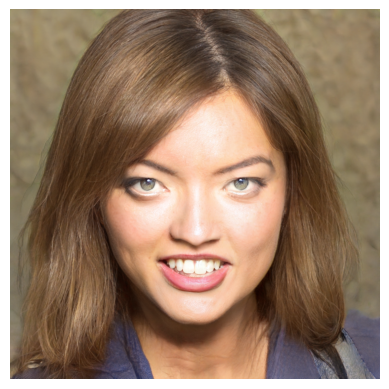

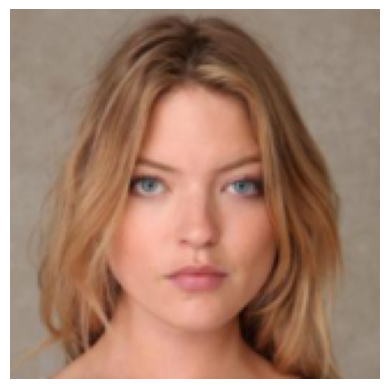

In [69]:
with torch.no_grad():
    final_high_res = generator(final_image)
    final_img = (final_high_res.clamp(-1, 1) + 1) / 2.0
    save_and_display_image(final_img, f"output.png")
    save_and_display_image(target_image, f"target.png")